In [8]:
import numpy as np
import pandas as pd
import os
from replay.data import Dataset, FeatureHint, FeatureInfo, FeatureSchema, FeatureType
from replay.data.dataset_utils import DatasetLabelEncoder
from replay.models import ALSWrap
from replay.metrics import HitRate, NDCG, Coverage
from scipy.sparse import csr_matrix
import scipy.sparse as sparse
import scipy
import matplotlib.pyplot as plt
from tqdm import tqdm
from replay.metrics import HitRate, NDCG, Coverage, Experiment
import warnings

In [10]:
import json

def parse(path):
    with open(path, 'r', encoding='utf-8') as g:
        for l in g:
            yield json.loads(l)

def getDF(path):
    i = 0
    df = {}
    for d in parse(path):
        df[i] = d
        i += 1
    return pd.DataFrame.from_dict(df, orient='index')

df = getDF(r"C:\Users\Anastasia_Golubova\Yandex.Disk\OTUS_Networks\hw_recommendation\AMAZON_FASHION_5.json")

In [17]:
style_df = df['style'].apply(pd.Series)
df = pd.concat([df, style_df], axis=1)

In [18]:
df

,overall,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,vote,image,Size:,Color:,Size Name:,Style:,0
0,5.0,True,"09 4, 2015",ALJ66O1Y6SLHA,B000K2PJ4K,"{'Size:': ' Big Boys', 'Color:': ' Blue/Orange'}",Tonya B.,Great product and price!,Five Stars,1441324800,NaN,NaN,Big Boys,Blue/Orange,NaN,NaN,NaN
1,5.0,True,"09 4, 2015",ALJ66O1Y6SLHA,B000K2PJ4K,"{'Size:': ' Big Boys', 'Color:': ' Black (3746...",Tonya B.,Great product and price!,Five Stars,1441324800,NaN,NaN,Big Boys,Black (37467610) / Red/White,NaN,NaN,NaN
2,5.0,True,"09 4, 2015",ALJ66O1Y6SLHA,B000K2PJ4K,"{'Size:': ' Big Boys', 'Color:': ' Blue/Gray L...",Tonya B.,Great product and price!,Five Stars,1441324800,NaN,NaN,Big Boys,Blue/Gray Logo,NaN,NaN,NaN
3,5.0,True,"09 4, 2015",ALJ66O1Y6SLHA,B000K2PJ4K,"{'Size:': ' Big Boys', 'Color:': ' Blue (37867...",Tonya B.,Great product and price!,Five Stars,1441324800,NaN,NaN,Big Boys,Blue (37867638-99) / Yellow,NaN,NaN,NaN
4,5.0,True,"09 4, 2015",ALJ66O1Y6SLHA,B000K2PJ4K,"{'Size:': ' Big Boys', 'Color:': ' Blue/Pink'}",Tonya B.,Great product and price!,Five Stars,1441324800,NaN,NaN,Big Boys,Blue/Pink,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171,5.0,True,"07 2, 2018",A2077NII5H62R2,B005AGO4LU,"{'Size:': ' 8.5 B(M) US', 'Color:': ' Green Gl...",Amazon Customer,Perfect fit!,Five Stars,1530489600,NaN,NaN,8.5 B(M) US,Green Glow/Seaweed - Hasta - White,NaN,NaN,NaN
3172,5.0,True,"06 28, 2018",A2IBS6PIPAGAB5,B005AGO4LU,"{'Size:': ' 5 B(M) US', 'Color:': ' Wolf Grey/...",J. Avila,My favorite cross trainers!,Comfortable,1530144000,NaN,NaN,5 B(M) US,Wolf Grey/Black-pink Blast/White,NaN,NaN,NaN
3173,5.0,True,"06 25, 2018",A1GTC5EVSJNCQ8,B005AGO4LU,"{'Size:': ' 8 B(M) US', 'Color:': ' Blue Tint/...",Amazon Customer,Love them fit perfect,Five Stars,1529884800,NaN,NaN,8 B(M) US,Blue Tint/Green Glow/Hasta/White,NaN,NaN,NaN
3174,5.0,True,"06 20, 2018",A311XHHLM12MUT,B005AGO4LU,"{'Size:': ' 9 B(M) US', 'Color:': ' Blue Tint/...",Peter,Favorite Nike shoe ever! The flex sole is exce...,Love them!,1529452800,NaN,NaN,9 B(M) US,Blue Tint/Green Glow/Hasta/White,NaN,NaN,NaN


In [21]:
## количество уникальных товаров
len(df['asin'].unique())

31

<Axes: xlabel='overall', ylabel='Count'>

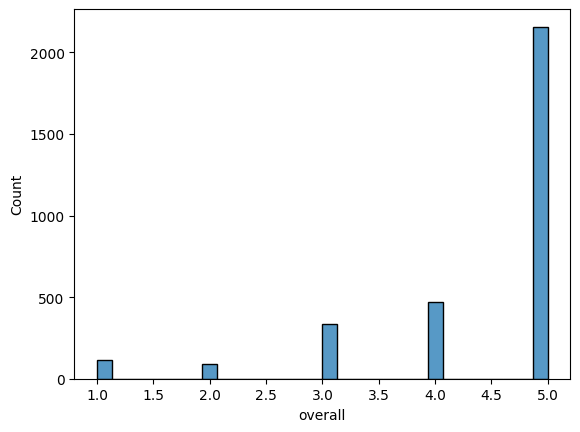

In [15]:
import seaborn as sns
sns.histplot(df['overall'])

In [49]:
data = df[['reviewerID', 'asin', 'unixReviewTime']].copy()

data = data.rename(columns={
    'reviewerID': 'query_id',
    'asin': 'item_id',
    'unixReviewTime': 'timestamp'
})

data = data.sort_values(['query_id', 'timestamp'])

In [28]:
data

,user_id,item_id,timestamp
497,A10RXRZE0TAKPU,B001IKJOLW,1462924800
860,A10RXRZE0TAKPU,B0058YEJ5K,1462924800
1215,A10RXRZE0TAKPU,B0014F7B98,1462924800
1583,A10RXRZE0TAKPU,B009MA34NY,1462924800
1952,A10RXRZE0TAKPU,B0092UF54A,1462924800
...,...,...,...
1460,AZYHPRWLMSY9O,B009MA34NY,1488758400
1829,AZYHPRWLMSY9O,B0092UF54A,1488758400
2199,AZYHPRWLMSY9O,B005AGO4LU,1488758400
2604,AZYHPRWLMSY9O,B010RRWKT4,1488758400


In [50]:
### train-test split: послдений товар каждого пользователя - в тест
test = data.groupby('query_id').tail(1).copy()
train = data.drop(test.index).copy()

### baseline model - рекомендуем популярные

In [51]:
### популярные товары по train
top_k = 10

popular_items = (
    train['item_id']
    .value_counts()
    .head(top_k)
    .index
    .tolist()
)

In [52]:
### одинаковые рекомендаиции для всех
users = test['query_id'].unique()

pred = pd.DataFrame(
    [(u, item, top_k - rank) 
     for u in users
     for rank, item in enumerate(popular_items)],
    columns=['query_id', 'item_id', 'rating']
)

In [53]:
pred

,query_id,item_id,rating
0,A10RXRZE0TAKPU,B0092UF54A,10
1,A10RXRZE0TAKPU,B009MA34NY,9
2,A10RXRZE0TAKPU,B010RRWKT4,8
3,A10RXRZE0TAKPU,B0014F7B98,7
4,A10RXRZE0TAKPU,B005AGO4LU,6
...,...,...,...
4055,AZYHPRWLMSY9O,B0058YEJ5K,5
4056,AZYHPRWLMSY9O,B001IKJOLW,4
4057,AZYHPRWLMSY9O,B000YFSR5G,3
4058,AZYHPRWLMSY9O,B000YFSR4W,2


In [54]:
### метрики
hr = HitRate(top_k)
ndcg = NDCG(top_k)
cov = Coverage(top_k)

print("HitRate@10:", hr(pred,test))
print("NDCG@10:", ndcg(pred,test))
print("Coverage@10:", cov(pred,train))

HitRate@10: {'HitRate@10': np.float64(0.9334975369458128)}
NDCG@10: {'NDCG@10': np.float64(0.27791207398956974)}
Coverage@10: {'Coverage@10': 0.4}


### HitRate@10 довольно высока, чт означает, что модель в целом неплохо рекомендует товары, однако NDCG@10 низкая, что значит модель рекомендует не самые предпочтительные товары

### Item-based cosine recommender

In [67]:
train_df = train.copy()
test_df = test.copy()

train_df["rating"] = 1
test_df["rating"] = 1

In [70]:
user_item = train_df.pivot_table(
    index="query_id",
    columns="item_id",
    values="rating",
    fill_value=0
)

In [71]:
### посчитаем cosine similarity между товарами

from sklearn.metrics.pairwise import cosine_similarity

item_sim = cosine_similarity(user_item.T)

item_sim = pd.DataFrame(
    item_sim,
    index=user_item.columns,
    columns=user_item.columns
)

In [72]:
def recommend(user, k=10):
    
    if user not in user_item.index:
        return []
    
    user_vector = user_item.loc[user]
    
    scores = item_sim.dot(user_vector)
    
    seen_items = user_vector[user_vector > 0].index
    
    scores = scores.drop(seen_items)
    
    return scores.sort_values(ascending=False).head(k).index.tolist()

In [74]:
top_k = 10

recs = []

for u in test_df["query_id"].unique():
    
    items = recommend(u, top_k)
    
    for rank, item in enumerate(items):
        
        recs.append(
            (u, item, top_k - rank)
        )

pred = pd.DataFrame(
    recs,
    columns=["query_id", "item_id", "rating"]
)

In [76]:
hr = HitRate(10)
ndcg = NDCG(10)
cov = Coverage(10)

print("HitRate:", hr(pred, test_df))
print("NDCG:", ndcg(pred, test_df))
print("Coverage:", cov(pred, train_df))

HitRate: {'HitRate@10': np.float64(0.9261083743842364)}
NDCG: {'NDCG@10': np.float64(0.9125076713956775)}
Coverage: {'Coverage@10': 0.92}


### SVD

In [78]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=15, random_state=42)

user_factors = svd.fit_transform(user_item)
item_factors = svd.components_

In [79]:
pred_matrix = np.dot(user_factors, item_factors)

pred_matrix = pd.DataFrame(
    pred_matrix,
    index=user_item.index,
    columns=user_item.columns
)

In [80]:
def recommend_svd(user, k=10):

    if user not in pred_matrix.index:
        return []

    scores = pred_matrix.loc[user]

    seen_items = user_item.loc[user]
    seen_items = seen_items[seen_items > 0].index

    scores = scores.drop(seen_items)

    return scores.sort_values(ascending=False).head(k).index.tolist()

In [82]:
top_k = 10

recs = []

for u in test_df["query_id"].unique():

    items = recommend_svd(u, top_k)

    for rank, item in enumerate(items):

        recs.append(
            (u, item, top_k - rank)
        )

pred = pd.DataFrame(
    recs,
    columns=["query_id", "item_id", "rating"]
)

In [83]:
hr = HitRate(10)
ndcg = NDCG(10)
cov = Coverage(10)

print("SVD HitRate:", hr(pred, test_df))
print("SVD NDCG:", ndcg(pred, test_df))
print("SVD Coverage:", cov(pred, train_df))

SVD HitRate: {'HitRate@10': np.float64(0.896551724137931)}
SVD NDCG: {'NDCG@10': np.float64(0.8779315943085861)}
SVD Coverage: {'Coverage@10': 1.0}


### модели на основе косинусного сходства товаров и SVD помогли улучшить метрики и рекомендовать более предпочтительные товары